In [ ]:
# Install the libraries Colab does not have (takes ~1 min)
!pip install -q pystac-client planetary-computer rioxarray osmnx leafmap

# Import them
import pystac_client, planetary_computer     # search + access satellite catalog
import rioxarray                              # read satellite images (rasters)
import geopandas as gpd, osmnx as ox          # vector data (buildings, roads)
import numpy as np, pandas as pd              # numbers and tables
import matplotlib.pyplot as plt               # plots

bbox = [-111.96, 33.41, -111.92, 33.44]       # Tempe: west, south, east, north

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 4.

It opens the Planetary Computer catalog, which works like a library index of satellite images.
It searches that catalog for Landsat images over Tempe from summer 2025 with less than 5% cloud cover.
It picks the clearest one.
It reads only the thermal band, cut to our box.
It converts the stored integers to °C using the USGS formula.

Scene: LC09_L2SP_037037_20250729_02_T1 | date: 2025-07-29 | cloud %: 0.0
Shape: (113, 126) | pixel size (m): (30.0, -30.0)
Min 35.9 °C | Max 62.1 °C


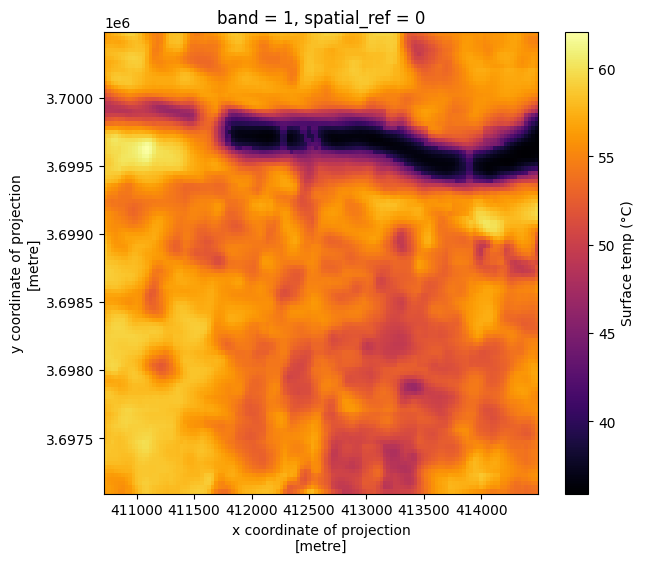

In [ ]:
# ============================================================
# BLOCK 8 — Module 2: Land surface temperature (the target)
# ============================================================
# WHAT IS THIS?
#   Landsat 8/9 carry a thermal sensor that measures how hot the
#   GROUND SURFACE is (roofs, roads, grass), not the air.
#   The heat is measured at ~100 m, then delivered on a 30 m grid,
#   so it looks blurry next to Sentinel-2 (10 m).
#   That blur is exactly why we will "downscale" it later.
#
# WHERE FROM?
#   Microsoft Planetary Computer, collection "landsat-c2-l2".
#   Band "lwir11" = surface temperature, stored as integers.
#   Convert with USGS formula:  Kelvin = value * 0.00341802 + 149.0
#   then Celsius = Kelvin - 273.15
# ------------------------------------------------------------

import pystac_client, planetary_computer, rioxarray

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace)

# 1) Find a clear summer scene over Tempe (hot season = clear contrast)
search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox,                                   # same Tempe box as Module 1
    datetime="2025-06-01/2025-08-31",
    query={"eo:cloud_cover": {"lt": 5}})
scene = min(search.items(), key=lambda s: s.properties["eo:cloud_cover"])
print("Scene:", scene.id, "| date:", scene.datetime.date(),
      "| cloud %:", scene.properties["eo:cloud_cover"])

# 2) Read the thermal band, cut to our box, convert to °C
lst = rioxarray.open_rasterio(scene.assets["lwir11"].href).squeeze()
lst = lst.rio.clip_box(*bbox, crs="EPSG:4326")
lst_c = lst.where(lst > 0) * 0.00341802 + 149.0 - 273.15   # 0 = no data

# 3) Look at it
print("Shape:", lst_c.shape, "| pixel size (m):", lst_c.rio.resolution())
print(f"Min {float(lst_c.min()):.1f} °C | Max {float(lst_c.max()):.1f} °C")
lst_c.plot(cmap="inferno", figsize=(7, 6), cbar_kwargs={"label": "Surface temp (°C)"})

Sentinel-2 scene: S2B_MSIL2A_20250730T180919_R084_T12SVC_20250730T213824


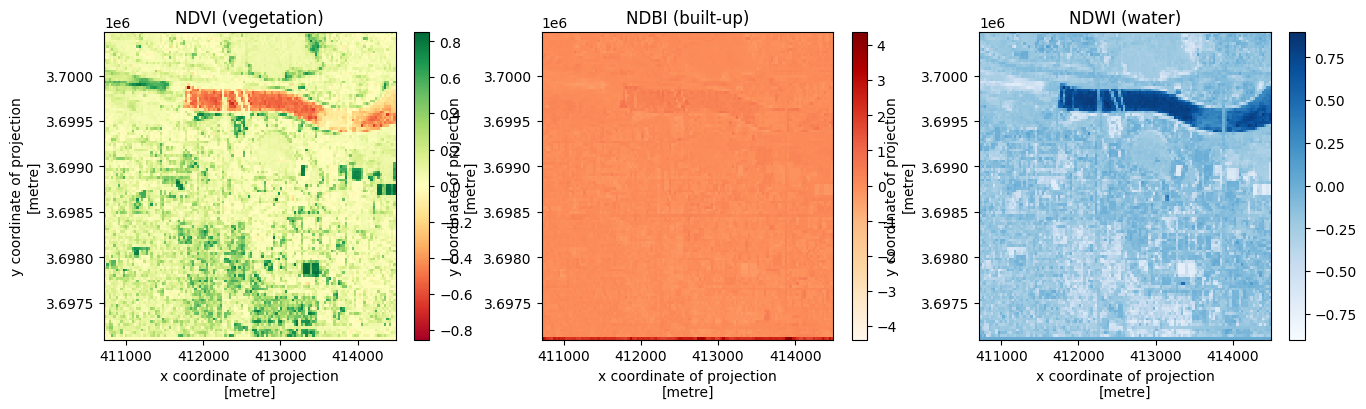

In [ ]:
# ============================================================
# BLOCK 9 — Index attributes from Sentinel-2 (features)
# ============================================================
# WHAT ARE INDICES?
#   Simple band maths that highlight one surface type:
#   NDVI = (NIR - Red)  / (NIR + Red)   -> green vegetation (high = plants)
#   NDBI = (SWIR - NIR) / (SWIR + NIR)  -> built-up / bare surfaces
#   NDWI = (Green - NIR)/ (Green + NIR) -> water (high = water)
#   All range from -1 to +1.
#
# NOTE: Since 2022, Sentinel-2 L2A values carry a +1000 offset.
#   We subtract 1000 so the band maths is correct.
# ------------------------------------------------------------
import xarray as xr

def load_band(href):
    """Open one band, cut it to Tempe, snap it onto the Landsat 30 m grid."""
    band = rioxarray.open_rasterio(href).squeeze()
    band = band.rio.clip_box(*bbox, crs="EPSG:4326")
    return band.rio.reproject_match(lst_c).astype("float32")

# Clear Sentinel-2 scene close to the Landsat date (2025-07-29)
s2_search = catalog.search(collections=["sentinel-2-l2a"], bbox=bbox,
                           datetime="2025-07-15/2025-08-15",
                           query={"eo:cloud_cover": {"lt": 5}})
s2 = min(s2_search.items(), key=lambda s: s.properties["eo:cloud_cover"])
print("Sentinel-2 scene:", s2.id)

green = load_band(s2.assets["B03"].href) - 1000
red   = load_band(s2.assets["B04"].href) - 1000
nir   = load_band(s2.assets["B08"].href) - 1000
swir  = load_band(s2.assets["B11"].href) - 1000

ndvi = (nir - red)   / (nir + red)
ndbi = (swir - nir)  / (swir + nir)
ndwi = (green - nir) / (green + nir)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ndvi.plot(ax=ax[0], cmap="RdYlGn"); ax[0].set_title("NDVI (vegetation)")
ndbi.plot(ax=ax[1], cmap="OrRd");   ax[1].set_title("NDBI (built-up)")
ndwi.plot(ax=ax[2], cmap="Blues");  ax[2].set_title("NDWI (water)")
plt.show()

<xarray.Dataset> Size: 401kB
Dimensions:      (x: 126, y: 113)
Coordinates:
  * x            (x) float64 1kB 4.107e+05 4.108e+05 ... 4.144e+05 4.145e+05
  * y            (y) float64 904B 3.7e+06 3.7e+06 ... 3.697e+06 3.697e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    ndvi         (y, x) float32 57kB -0.03022 0.03976 0.04846 ... -0.0 -0.0 -0.0
    ndbi         (y, x) float32 57kB 0.02809 0.1719 0.05796 ... 2.03 2.923 2.233
    ndwi         (y, x) float32 57kB -0.03603 -0.162 -0.2215 ... -0.0 -0.0 -0.0
    elev         (y, x) float32 57kB nan 355.3 352.0 351.1 ... 360.2 358.6 nan
    bld_frac     (y, x) float64 114kB 0.0 0.0 0.0 0.0 0.0 ... 0.3 0.29 0.0 0.0
    lst          (y, x) float32 57kB 56.3 56.88 57.29 57.59 ... 53.59 53.72 53.8


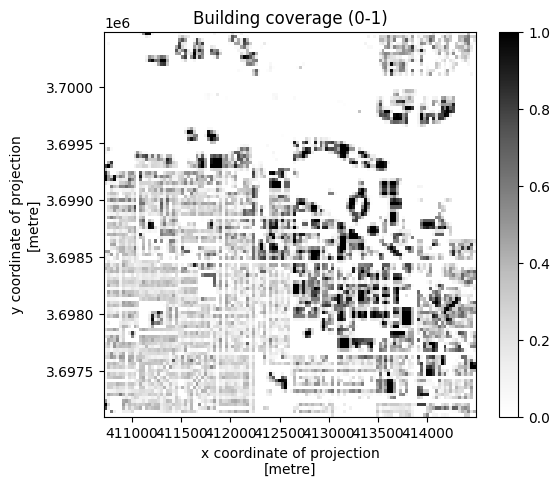

In [ ]:
# ============================================================
# BLOCK 10 — More features: elevation + building coverage
# ============================================================
# Elevation: Copernicus DEM (same as Module 1)
# Building coverage: share of each 30 m pixel covered by OSM roofs.
#   Trick: draw buildings on a 10x finer grid (3 m), then average
#   each 10x10 block -> fraction between 0 (no roof) and 1 (all roof).
# ------------------------------------------------------------
from rasterio import features
from affine import Affine

dem = next(catalog.search(collections=["cop-dem-glo-30"], bbox=bbox).items())
elev = load_band(dem.assets["data"].href)

buildings = ox.features_from_bbox(bbox=tuple(bbox), tags={"building": True})
buildings = buildings[buildings.geom_type.isin(["Polygon", "MultiPolygon"])]
buildings = buildings.to_crs(lst_c.rio.crs)            # metres, same as Landsat

h, w = lst_c.shape
fine = features.rasterize(buildings.geometry, out_shape=(h * 10, w * 10),
                          transform=lst_c.rio.transform() * Affine.scale(0.1))
bld_frac = lst_c.copy(data=fine.reshape(h, 10, w, 10).mean(axis=(1, 3)))

# Put everything in ONE container: same grid, one layer per feature
feats = xr.Dataset({"ndvi": ndvi, "ndbi": ndbi, "ndwi": ndwi,
                    "elev": elev, "bld_frac": bld_frac, "lst": lst_c})
print(feats)
bld_frac.plot(cmap="Greys", figsize=(6, 5)); plt.title("Building coverage (0-1)"); plt.show()

In [ ]:
# ============================================================
# BLOCK 11 — Training table (120 m) + feature grid at 10 m
# ============================================================
# DOWNSCALING STORY:
#   Landsat truly "sees" heat at ~100 m (blurry).
#   Sentinel-2 sees surfaces at 10 m (sharp).
#   -> TRAIN where heat is trustworthy: 120 m cells
#   -> PREDICT where features are sharp: 10 m pixels
#
# make_features(grid) = the SAME recipe as Blocks 9-10,
#   but for any grid we choose (30 m, 10 m, ...).
# ------------------------------------------------------------
cols = ["ndvi", "ndbi", "ndwi", "elev", "bld_frac"]

def make_features(grid):
    """Build the 5 features on the given grid."""
    def load(href):
        b = rioxarray.open_rasterio(href).squeeze().rio.clip_box(*bbox, crs="EPSG:4326")
        return b.rio.reproject_match(grid).astype("float32")
    g, r = load(s2.assets["B03"].href) - 1000, load(s2.assets["B04"].href) - 1000
    n, s = load(s2.assets["B08"].href) - 1000, load(s2.assets["B11"].href) - 1000
    h, w = grid.shape
    roofs = features.rasterize(buildings.geometry, out_shape=(h * 10, w * 10),
                               transform=grid.rio.transform() * Affine.scale(0.1))
    return xr.Dataset({
        "ndvi": (n - r) / (n + r),
        "ndbi": (s - n) / (s + n),
        "ndwi": (g - n) / (g + n),
        "elev": load(dem.assets["data"].href),
        "bld_frac": grid.copy(data=roofs.reshape(h, 10, w, 10).mean(axis=(1, 3)))})

# 1) Training data: average 4x4 Landsat pixels -> 120 m cells
coarse = feats.coarsen(x=4, y=4, boundary="trim").mean()
coarse_df = coarse.to_dataframe()[cols + ["lst"]].dropna()
print("Training cells (120 m):", len(coarse_df))
print(coarse_df.corr()["lst"].round(2))            # + = hotter, - = cooler

# 2) Spatial split: hold out the eastern 25% as unseen area
x_pos = coarse_df.index.get_level_values("x").to_numpy()
is_test = x_pos > np.quantile(x_pos, 0.75)
train, test = coarse_df[~is_test], coarse_df[is_test]
print("Train:", len(train), "| Test:", len(test))

# 3) The sharp 10 m grid we will predict on
grid10 = lst_c.rio.reproject(lst_c.rio.crs, resolution=10)   # just a template
feats10 = make_features(grid10)
print("10 m grid shape:", grid10.shape)

Training cells (120 m): 868
ndvi        0.41
ndbi       -0.19
ndwi       -0.66
elev        0.21
bld_frac    0.10
lst         1.00
Name: lst, dtype: float64
Train: 672 | Test: 196
10 m grid shape: (339, 378)


Check 1 - unseen east, 120 m: R² = 0.87 | RMSE = 1.68 °C
Check 2 - 10 m map averaged to 30 m vs Landsat: R² = 0.74 | RMSE = 2.32 °C


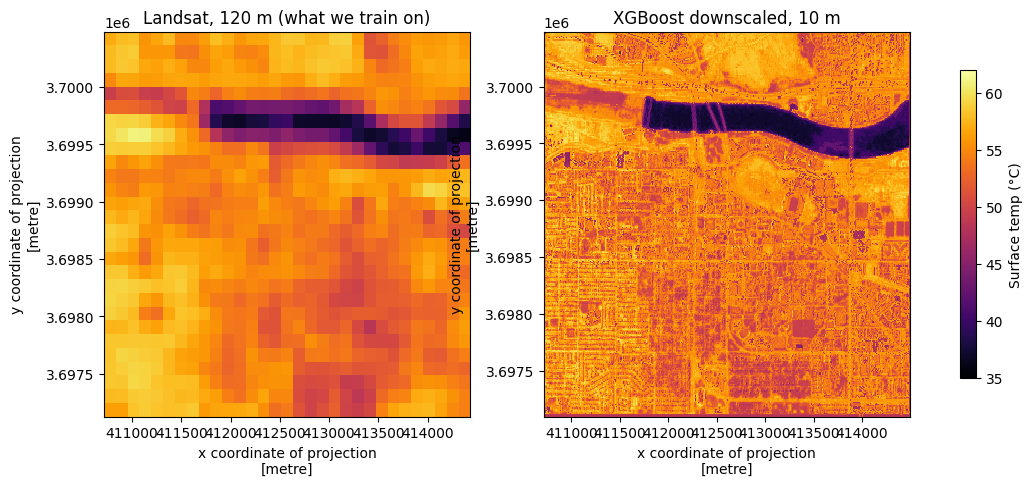

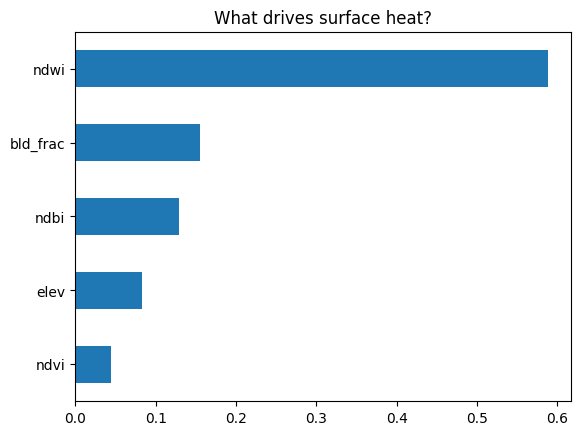

In [ ]:
# ============================================================
# BLOCK 12 — XGBoost: learn at 120 m, predict heat at 10 m
# ============================================================
# XGBoost = many small decision trees, each fixing the previous
#   one's mistakes. Captures non-linear effects (roofs heat fast,
#   then level off) that a straight line misses.
#
# TWO CHECKS:
#   1) Unseen east area (120 m): does it work in new places?
#   2) Consistency: average our 10 m map back to 30 m and compare
#      with Landsat 30 m. A good downscaled map should agree.
# ------------------------------------------------------------
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

model = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05)
model.fit(train[cols], train["lst"])

def score(name, true, pred):
    ok = ~np.isnan(true) & ~np.isnan(pred)
    rmse = mean_squared_error(true[ok], pred[ok]) ** 0.5
    print(f"{name}: R² = {r2_score(true[ok], pred[ok]):.2f} | RMSE = {rmse:.2f} °C")

score("Check 1 - unseen east, 120 m", test["lst"].to_numpy(), model.predict(test[cols]))

# Predict every 10 m pixel (table of features -> heat -> back to a map)
X10 = pd.DataFrame({c: feats10[c].values.ravel() for c in cols})
pred10 = grid10.copy(data=model.predict(X10).reshape(grid10.shape))
pred10 = pred10.where(feats10["ndvi"].notnull())

back_to_30 = pred10.coarsen(x=3, y=3, boundary="trim").mean()
score("Check 2 - 10 m map averaged to 30 m vs Landsat",
      lst_c.values.ravel(), back_to_30.values.ravel())

# The visual: blurry -> sharper -> sharpest
fig, ax = plt.subplots(1, 2, figsize=(13, 5))                 # was (1, 3)
opts = dict(cmap="inferno", vmin=35, vmax=62, add_colorbar=False)
coarse["lst"].plot(ax=ax[0], **opts); ax[0].set_title("Landsat, 120 m (what we train on)")
im = pred10.plot(ax=ax[1], **opts);   ax[1].set_title("XGBoost downscaled, 10 m")   # ax[2] -> ax[1]
fig.colorbar(im, ax=ax, label="Surface temp (°C)", shrink=0.8)
plt.show()

pd.Series(model.feature_importances_, index=cols).sort_values().plot.barh(title="What drives surface heat?")
plt.show()

pred10.rio.to_raster("tempe_lst_10m.tif")   # saved for what-if + LLM/VLM module